# 03 — Modèles Machine Learning

**Modèles entraînés** : Logistic Regression, Random Forest, Gradient Boosting, SVM, KNN, XGBoost  
**Données** : X_train/X_test depuis `data/processed/` (preprocessées, équilibrées par SMOTE)


### 1 - Chargement & vue d'ensemble 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
C = {'sain': '#2ecc71', 'malade': '#e74c3c'}

DATA_PATH = Path('../data/raw/heart_disease_uci.csv')
FIGS_PATH = Path('../reports/figures')
FIGS_PATH.mkdir(parents=True, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
df['target']       = (df['num'] > 0).astype(int)
df['target_label'] = df['target'].map({0: 'Sain', 1: 'Malade'})

NUM_COLS = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
CAT_COLS = ['sex', 'cp', 'restecg', 'slope', 'thal']

print(f'Shape : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes')
df_raw.head(8)

Shape : 920 lignes × 16 colonnes


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0


In [2]:
print('--- Types ---')
print(df_raw.dtypes)
print()
print('--- Valeurs uniques (catégorielles) ---')
for col in ['sex', 'cp', 'restecg', 'slope', 'thal', 'dataset', 'fbs', 'exang']:
    print(f'  {col:12s}: {list(df_raw[col].dropna().unique())}')

--- Types ---
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

--- Valeurs uniques (catégorielles) ---
  sex         : ['Male', 'Female']
  cp          : ['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
  restecg     : ['lv hypertrophy', 'normal', 'st-t abnormality']
  slope       : ['downsloping', 'flat', 'upsloping']
  thal        : ['fixed defect', 'normal', 'reversable defect']
  dataset     : ['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
  fbs         : [True, False]
  exang       : [False, True]


In [3]:
print('--- Statistiques descriptives ---')
df_raw.describe(include='all')

--- Statistiques descriptives ---


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


### 2 - Analyse de la cible

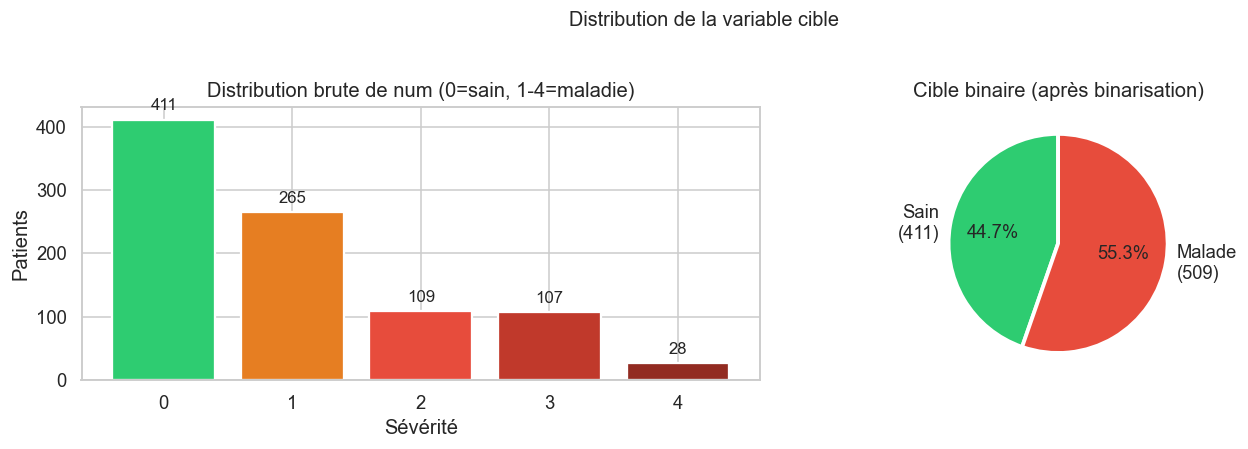


Ratio malades : 55.3%  →  léger déséquilibre, traitement par SMOTE nécessaire


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution brute 0-4
counts_raw = df['num'].value_counts().sort_index()
palette = ['#2ecc71', '#e67e22', '#e74c3c', '#c0392b', '#922b21']
bars = axes[0].bar(counts_raw.index.astype(str), counts_raw.values,
                   color=palette, edgecolor='white', linewidth=1.5)
axes[0].bar_label(bars, padding=4, fontsize=11)
axes[0].set_title('Distribution brute de num (0=sain, 1-4=maladie)')
axes[0].set_xlabel('Sévérité')
axes[0].set_ylabel('Patients')

# Distribution binaire
counts_bin = df['target'].value_counts().sort_index()
axes[1].pie(counts_bin.values,
            labels=[f'Sain\n({counts_bin[0]})', f'Malade\n({counts_bin[1]})'],
            autopct='%1.1f%%',
            colors=[C['sain'], C['malade']],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
            textprops={'fontsize': 12})
axes[1].set_title('Cible binaire (après binarisation)')

plt.suptitle('Distribution de la variable cible', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGS_PATH / '01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nRatio malades : {df["target"].mean():.1%}  →  léger déséquilibre, traitement par SMOTE nécessaire')